# Introduction à la Convolution

In [26]:
# import
import matplotlib.pyplot as plt; from scipy.io import wavfile
%run ./init.py

## Créer une réverbération à la main

Pour ajouter de la reverb à un enregistrement trop sec, on émule "ce qui se serait passé s'il avait été réalisé dans une salle". 
Pour ça, on crée manuellement des "réflexions" du signal : des versions retardées et atténuées qu'on additionne entre elles.

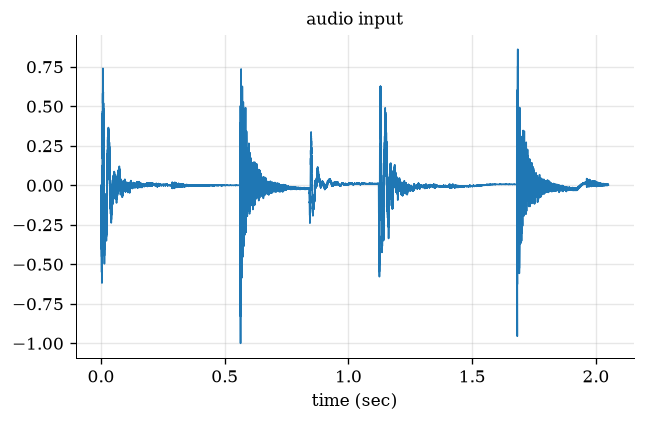

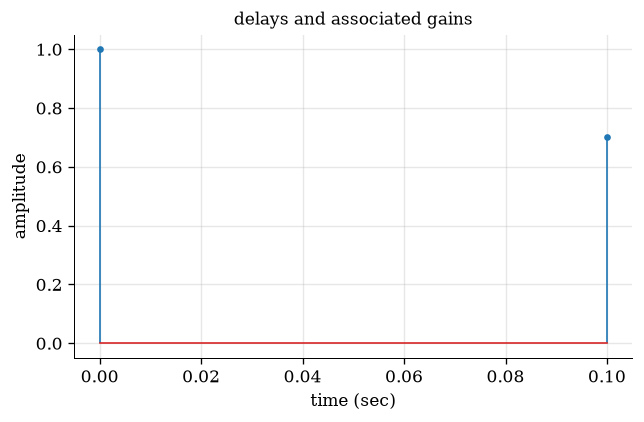

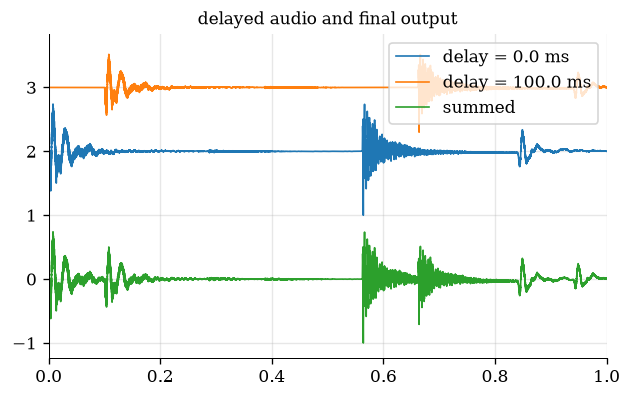

In [27]:
# define reverb configs (delays in ms)
reverb = {'gains':[1, 0.7], 'delays': [0, 100]} 
# reverb = {'gains':[1, 0.8, 0.6, 0.5, 0.4, 0.3], 'delays': [0, 11, 31, 43, 51, 75]} 

# load audio file
audio_in, fs = wavread('assets/drums.wav')

# play 
playsound(audio_in, fs)

# plot
t = np.arange(0, len(audio_in)) / fs
plt.plot(t, audio_in);
plt.title('audio input'); plt.xlabel('time (sec)'); plt.show()

# plot
plt.stem([x/1000 for x in reverb['delays']], reverb['gains']);
plt.title('delays and associated gains'); 
plt.xlabel('time (sec)'); plt.ylabel('amplitude'); plt.show()

# convert delays to number of samples
reverb['delays'] = [int(fs * x/1000) for x in reverb["delays"]]
max_delay_in_sample = np.max(reverb['delays'])

# init output
audio_out = np.zeros( len(audio_in) + max(reverb["delays"]) )
t = np.arange(0, len(audio_out)) / fs

# loop over tap delays
for i_tap in range(len(reverb["delays"])):

    # get delay and gain
    n = reverb["delays"][i_tap]
    g = reverb["gains"][i_tap]
    
    # create delayed audio tap
    audio_tap = g * np.pad(audio_in, (n, len(audio_out) - len(audio_in) - n))

    # plot
    plt.plot(t, audio_tap + i_tap + 2, label = f'delay = {1000*n/fs} ms')

    # add tap to output
    audio_out += audio_tap

# normalise output gain
audio_out /= max(1, np.max(np.abs(audio_out)))

# play 
playsound(audio_out, fs)

# plot
plt.plot(t, audio_out, label = 'summed');
plt.title('delayed audio and final output')
plt.xlim([0, 1]); plt.legend(loc = 'upper right'); 
plt.show()

Pour créer une réverb naturelle, on s'inspire de gains/atténuations mesurés dans une salle réelle.
Pour les mesurer, on émet typiquement un son très court (e.g. coup de feu) dans cette salle.
Sur l'enregistrement de ce son, cette **réponse impulsionnelle**, on retrouve les pics d'énergie qui correspondent au son direct et aux réflexions successives du son dans la salle.

## Créer une réverbération à partir d'une réponse impulsionnelle

Ci-dessous, la réponse impulsionnelle d'une salle `ir_mono.wav` est utilisée pour créer la reverb.

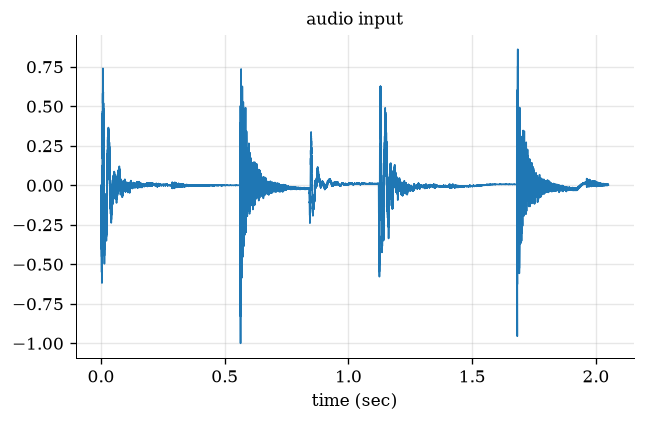

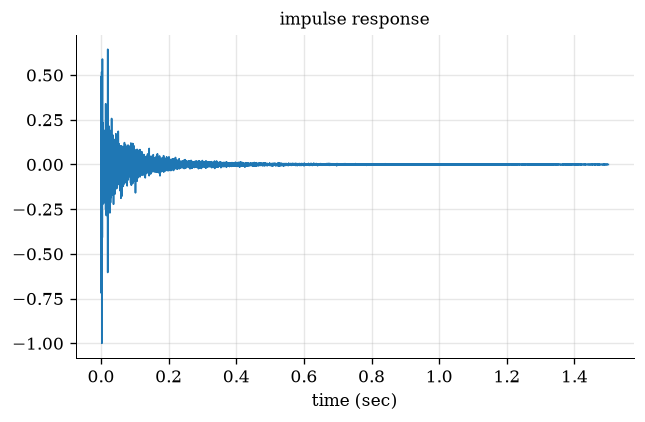

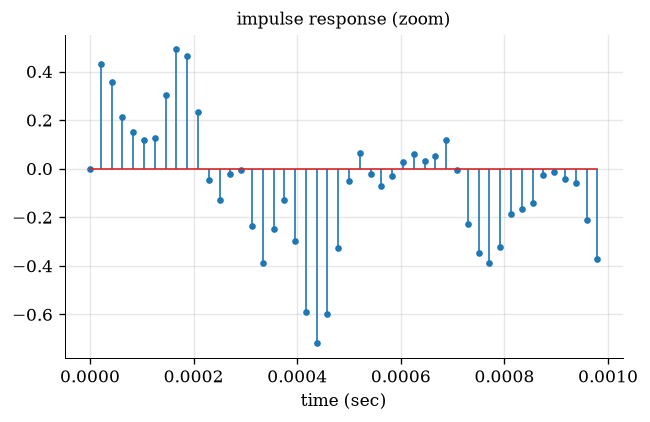

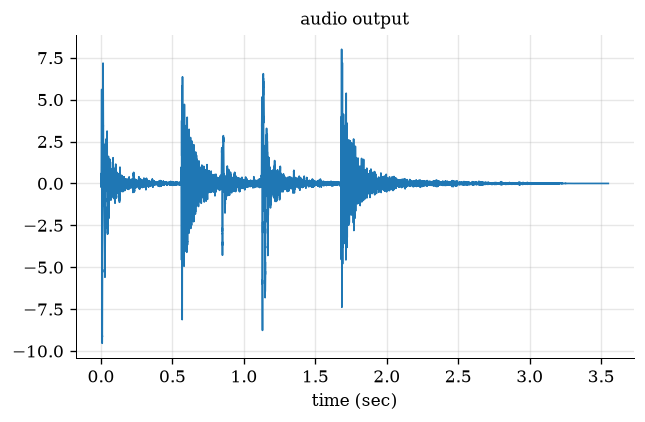

In [28]:
# load audio file
audio_in, fs = wavread('assets/drums.wav')

# play 
playsound(audio_in, fs)

# plot
t = np.arange(0, len(audio_in))/fs
plt.plot(t, audio_in); 
plt.title('audio input'); plt.xlabel('time (sec)'); plt.show()

# load impulse response
ir, fs = wavread('assets/ir_mono.wav')
ir = ir / np.max(np.abs(ir))

# play 
playsound(ir, fs)

# plot
t = np.arange(0, len(ir))/fs
plt.plot(t, ir); 
plt.title('impulse response'); plt.xlabel('time (sec)'); plt.show()
#
selvect = np.arange(0, int(0.001*fs))
t = np.arange(0, len(ir))/fs
plt.stem(t[selvect], ir[selvect]); 
plt.title('impulse response (zoom)'); plt.xlabel('time (sec)'); plt.show()

# convolve
audio_out = np.convolve(audio_in, ir)

# play 
playsound(audio_out, fs)

# plot
t = np.arange(0, len(audio_out))/fs
plt.plot(t, audio_out); 
plt.title('audio output'); plt.xlabel('time (sec)'); plt.show()

Dans les deux exemples ci-dessus, cette addition de versions retardées et atténuées du signal s'écrit, pour un signal x(n) et une réponse impulsionnelle h(n) : 

$ y(n) = h(0) . x(n) + h(1) . x(n-1) + ... + h(K) . x(n-K) $

$ y(n) = \sum_{k = 0}^{K} h(k) . x(n-k)$

$ y(n) = h(n) \circledast x(n) $

i.e. $y$ est la **convolution** entre $h$ et $x$.

$h$ dans cet exemple et le précédant est appelé une FIR ou **Finite Impulse Response**.

## Resources additionnelles

- 3Blue1Brown video: [But what is a convolution?](https://www.youtube.com/watch?v=KuXjwB4LzSA&)